In [160]:
import numpy as np
import pandas as pd
import os 
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split

In [161]:
df = pd.read_csv('archive/train.csv')


In [162]:
df

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0
...,...,...
3657,ffa47f6a7bf4,2
3658,ffc04fed30e6,0
3659,ffcf7b45f213,2
3660,ffd97f8cd5aa,0


In [163]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [164]:
print(tf.__version__)


2.15.0


In [165]:
import os
for dirname, _, filenames in os.walk('archive/colored_images'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


archive/colored_images/.DS_Store
archive/colored_images/Mild/2d7666b8884f.png
archive/colored_images/Mild/50840c36f0b4.png
archive/colored_images/Mild/30cab14951ac.png
archive/colored_images/Mild/a8582e346df0.png
archive/colored_images/Mild/cab3dfa7962d.png
archive/colored_images/Mild/35d6c4c50072.png
archive/colored_images/Mild/67f5d89da548.png
archive/colored_images/Mild/6b07971c3bf6.png
archive/colored_images/Mild/7116128c65ab.png
archive/colored_images/Mild/e38f3a65b02b.png
archive/colored_images/Mild/d85588ff2ebd.png
archive/colored_images/Mild/a19ecd0a706e.png
archive/colored_images/Mild/49c5e7f6b8d2.png
archive/colored_images/Mild/2f2e1949ad56.png
archive/colored_images/Mild/35aa7f5c2ec0.png
archive/colored_images/Mild/55eac26bd383.png
archive/colored_images/Mild/af133a85ea0c.png
archive/colored_images/Mild/80a02014b418.png
archive/colored_images/Mild/384631079d1e.png
archive/colored_images/Mild/e25ccfe38e44.png
archive/colored_images/Mild/6ea07d19b4ce.png
archive/colored_images

In [166]:
directory_path = '/Users/mueedhussain/Desktop/CNN Model/archive/colored_images'

In [167]:
import os

if os.path.exists(directory_path):
    print(f"Directory exists: {directory_path}")
else:
    print(f"Directory does not exist: {directory_path}")

Directory exists: /Users/mueedhussain/Desktop/CNN Model/archive/colored_images


In [168]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [169]:
train_data = datagen.flow_from_directory(directory_path,
                                         target_size=(224,224),
                                         batch_size=32,
                                         class_mode='categorical',
                                         subset='training')

valid_data = datagen.flow_from_directory(directory_path,
                                         target_size=(224,224),
                                         batch_size=32,
                                         class_mode='categorical',
                                         subset='validation')


Found 2931 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


In [170]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense


In [171]:
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(224, 224, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(5))  # 5 classes
model.add(Activation('softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


In [185]:
history = model.fit(
    train_data,
    steps_per_epoch=train_data.samples // train_data.batch_size,
    epochs=20,  # Train for 20 epochs
    validation_data=valid_data,
    validation_steps=valid_data.samples // valid_data.batch_size
)


    # printing information about he training progress for each epoch
    print(f"Epoch {epoch+1}/{20} - Loss: {history.history['loss'][0]}, Validation Loss: {history.history['val_loss'][0]}")



Epoch 1/20
91/91 [==============================] - 85s 929ms/step - loss: 0.7716 - accuracy: 0.7282 - val_loss: 0.7658 - val_accuracy: 0.7216
Epoch 2/20
91/91 [==============================] - 94s 1s/step - loss: 0.7764 - accuracy: 0.7216 - val_loss: 0.7652 - val_accuracy: 0.7216
Epoch 3/20
91/91 [==============================] - 94s 1s/step - loss: 0.7654 - accuracy: 0.7275 - val_loss: 0.7470 - val_accuracy: 0.7244
Epoch 4/20
91/91 [==============================] - 94s 1s/step - loss: 0.7591 - accuracy: 0.7320 - val_loss: 0.7534 - val_accuracy: 0.7287
Epoch 5/20
91/91 [==============================] - 100s 1s/step - loss: 0.7590 - accuracy: 0.7282 - val_loss: 0.7718 - val_accuracy: 0.7188
Epoch 6/20
91/91 [==============================] - 104s 1s/step - loss: 0.7467 - accuracy: 0.7323 - val_loss: 0.8035 - val_accuracy: 0.7216
Epoch 7/20
91/91 [==============================] - 93s 1s/step - loss: 0.7640 - accuracy: 0.7247 - val_loss: 0.7550 - val_accuracy: 0.7301
Epoch 8/20
91/9

In [186]:
pd.DataFrame(history.history)

,loss,accuracy,val_loss,val_accuracy
0,0.771596,0.728182,0.765809,0.721591
1,0.776400,0.721628,0.765167,0.721591
2,0.765423,0.727492,0.746958,0.724432
3,0.759085,0.731977,0.753402,0.728693
4,0.758984,0.728182,0.771754,0.718750
5,0.746728,0.732322,0.803483,0.721591
6,0.763965,0.724733,0.755013,0.730114
7,0.759445,0.730597,0.746715,0.725852
8,0.749168,0.730597,0.739072,0.717330
9,0.751716,0.728872,0.751967,0.704545


Text(0, 0.5, 'Accuracy')

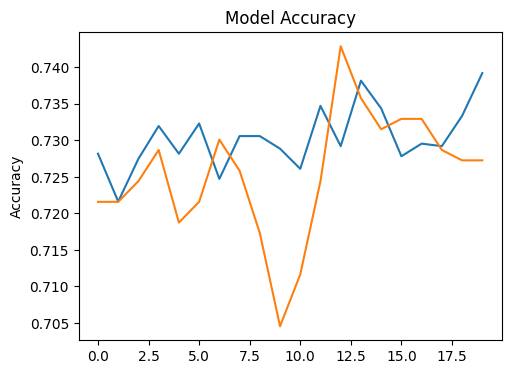

In [187]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')


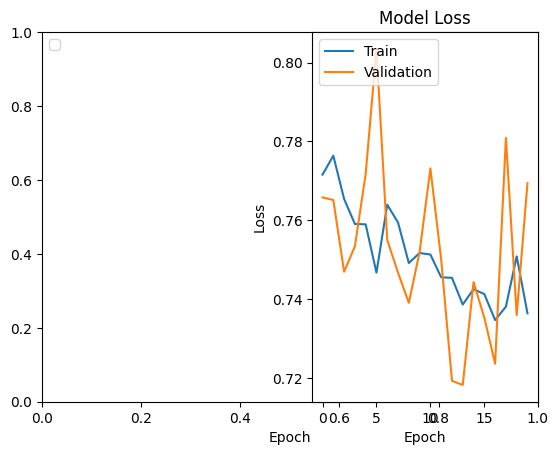

In [188]:
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


In [189]:
# Save the model
model.save('diabetic_retinopathy_model.h5')



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [193]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Paths
root_dir = '/Users/mueedhussain/Desktop/CNN Model'
data_dir = os.path.join(root_dir, 'archive/colored_images')
train_dir = os.path.join(root_dir, 'train')
validation_dir = os.path.join(root_dir, 'validation')
test_dir = os.path.join(root_dir, 'test')

# Create directories if they don't exist
for dir in [train_dir, validation_dir, test_dir]:
    if not os.path.exists(dir):
        os.makedirs(dir)

# Function to split data and move files
def split_and_move_files(class_dir, train_dir, validation_dir, test_dir, test_size=0.4):
    files = os.listdir(class_dir)
    train_files, test_files = train_test_split(files, test_size=test_size, random_state=42)
    validation_files, test_files = train_test_split(test_files, test_size=0.5, random_state=42)

    # Function to move files
    def move_files(files, source_dir, dest_dir):
        for f in files:
            shutil.move(os.path.join(source_dir, f), os.path.join(dest_dir, f))

    # Creating subdirectories for each class in train, validation and test directories
    for dir in [train_dir, validation_dir, test_dir]:
        class_subdir = os.path.join(dir, os.path.basename(class_dir))
        if not os.path.exists(class_subdir):
            os.makedirs(class_subdir)

    # Move the files
    move_files(train_files, class_dir, os.path.join(train_dir, os.path.basename(class_dir)))
    move_files(validation_files, class_dir, os.path.join(validation_dir, os.path.basename(class_dir)))
    move_files(test_files, class_dir, os.path.join(test_dir, os.path.basename(class_dir)))

# Splitting and moving files for each class
conditions = ['mild', 'moderate', 'severe', 'NO_DR', 'Proliferate_DR']
for condition in conditions:
    class_dir = os.path.join(data_dir, condition)
    split_and_move_files(class_dir, train_dir, validation_dir, test_dir)


In [198]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def scale_images(image):
    return image / 255.0

train_datagen = ImageDataGenerator(preprocessing_function=scale_images)
validation_datagen = ImageDataGenerator(preprocessing_function=scale_images)
test_datagen = ImageDataGenerator(preprocessing_function=scale_images)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

valid_data = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)


Found 2196 images belonging to 5 classes.
Found 733 images belonging to 5 classes.
Found 733 images belonging to 5 classes.


In [198]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def scale_images(image):
    return image / 255.0

train_datagen = ImageDataGenerator(preprocessing_function=scale_images)
validation_datagen = ImageDataGenerator(preprocessing_function=scale_images)
test_datagen = ImageDataGenerator(preprocessing_function=scale_images)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

valid_data = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)


Found 2196 images belonging to 5 classes.
Found 733 images belonging to 5 classes.
Found 733 images belonging to 5 classes.


In [202]:
from tensorflow.keras.models import load_model

model = load_model('/Users/mueedhussain/Desktop/CNN Model/diabetic_retinopathy_model.h5')


In [237]:
loss, accuracy = model.evaluate(test_data)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")


23/23 [==============================] - 6s 241ms/step - loss: 0.7571 - accuracy: 0.7162
Test Loss: 0.75711989402771
Test Accuracy: 0.7162346243858337


In [238]:
predictions = model.predict(test_data)

23/23 [==============================] - 5s 222ms/step


In [240]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Get the true labels from the test data generator
true_labels = test_data.classes

# Calculate predictions
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

# Create the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_classes)

# Create a DataFrame for the confusion matrix with labeled rows and columns
confusion_df = pd.DataFrame(conf_matrix, columns=conditions, index=conditions)

# Print the confusion matrix
print("Confusion Matrix:")
print(confusion_df)


23/23 [==============================] - 5s 228ms/step
Confusion Matrix:
                mild  moderate  severe  NO_DR  Proliferate_DR
mild             352         0       0      9               0
moderate           5         0       0     54               0
severe             4         0       0     70               0
NO_DR             28         0       0    172               0
Proliferate_DR     3         0       0     35               1


In [248]:
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)


23/23 [==============================] - 5s 212ms/step


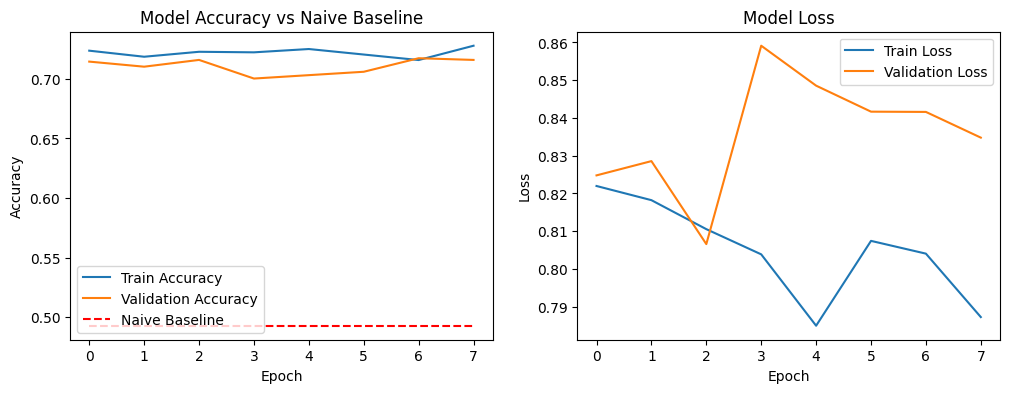

In [252]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculat the class distribution in the diagnosis column
class_distribution = df['diagnosis'].value_counts(normalize=True)
naive_baseline_accuracy = class_distribution.max()

# Plotting the baseline and actual performance
plt.figure(figsize=(12, 4))

# Model Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.hlines(naive_baseline_accuracy, xmin=0, xmax=len(history.history['accuracy'])-1, colors='r', linestyles='dashed', label='Naive Baseline')
plt.title('Model Accuracy vs Naive Baseline')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Model Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()
